In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '{: .2f}'. format(x))
np.set_printoptions(suppress=True) 


In [105]:
df_cust = pd.read_csv(r"C:\vs code programming\.vscode\NewCfile\Codebasics_ML\loan_prediction_project\customers.csv")
df_loan = pd.read_csv(r"C:\vs code programming\.vscode\NewCfile\Codebasics_ML\loan_prediction_project\loans.csv")
df_bureau = pd.read_csv(r"C:\vs code programming\.vscode\NewCfile\Codebasics_ML\loan_prediction_project\bureau_data.csv")

In [106]:
df_cust.shape , df_loan.shape , df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [107]:
df = pd.merge(df_cust, df_loan , on = 'cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [108]:
df = pd.merge(df , df_bureau)
df.head(3)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58


In [109]:
#default is our target column (its in boolean but its suitable in int format)
df['default'] = df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

Clearly there is a class imbalance


#### now we will check for data leakage as there is is class imbalance. It occurs when info from outside the training dataset is unintentionally used to train or evaluate a model

In [110]:
X = df.drop('default' , axis = 1)
y = df['default']

X_train , X_test , y_train , y_test =  train_test_split(X, y,stratify=y, test_size = 0.25, random_state = 42)

In [111]:
df_train = pd.concat([X_train , y_train], axis = 'columns')
df_test = pd.concat([X_test , y_test], axis = 'columns')
df_train.head()
df_train.shape

(37500, 33)

### Data Cleaning

In [112]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

Instead of deleting the nulls..we can replace them. For a categorical column, the best way is mode

In [113]:
mode_res = df_train.residence_type.mode()
mode_res

0    Owned
Name: residence_type, dtype: str

In [114]:
df_train['residence_type'] = df_train['residence_type'].fillna(mode_res)

In [115]:
df_test['residence_type'] = df_test['residence_type'].fillna(mode_res)

outlier visualization

In [116]:
contd_cols = [
    'age',
    'income',
    'number_of_dependants',
    'years_at_current_address',
    'sanction_amount',
    'loan_amount',
    'processing_fee',
    'gst',
    'net_disbursement',
    'loan_tenure_months',
    'principal_outstanding',
    'bank_balance_at_application',
    'number_of_open_accounts',
    'number_of_closed_accounts',
    'total_loan_months',
    'delinquent_months',
    'total_dpd',
    'enquiry_count',
    'credit_utilization_ratio'
]

categ_cols = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'city',
    'state',
    'loan_purpose',
    'loan_type',
    'default'
]
id_cols = [
    'cust_id',
    'loan_id',
    'zipcode'
]

date_cols = [
    'disbursal_date',
    'installment_start_dt'
]


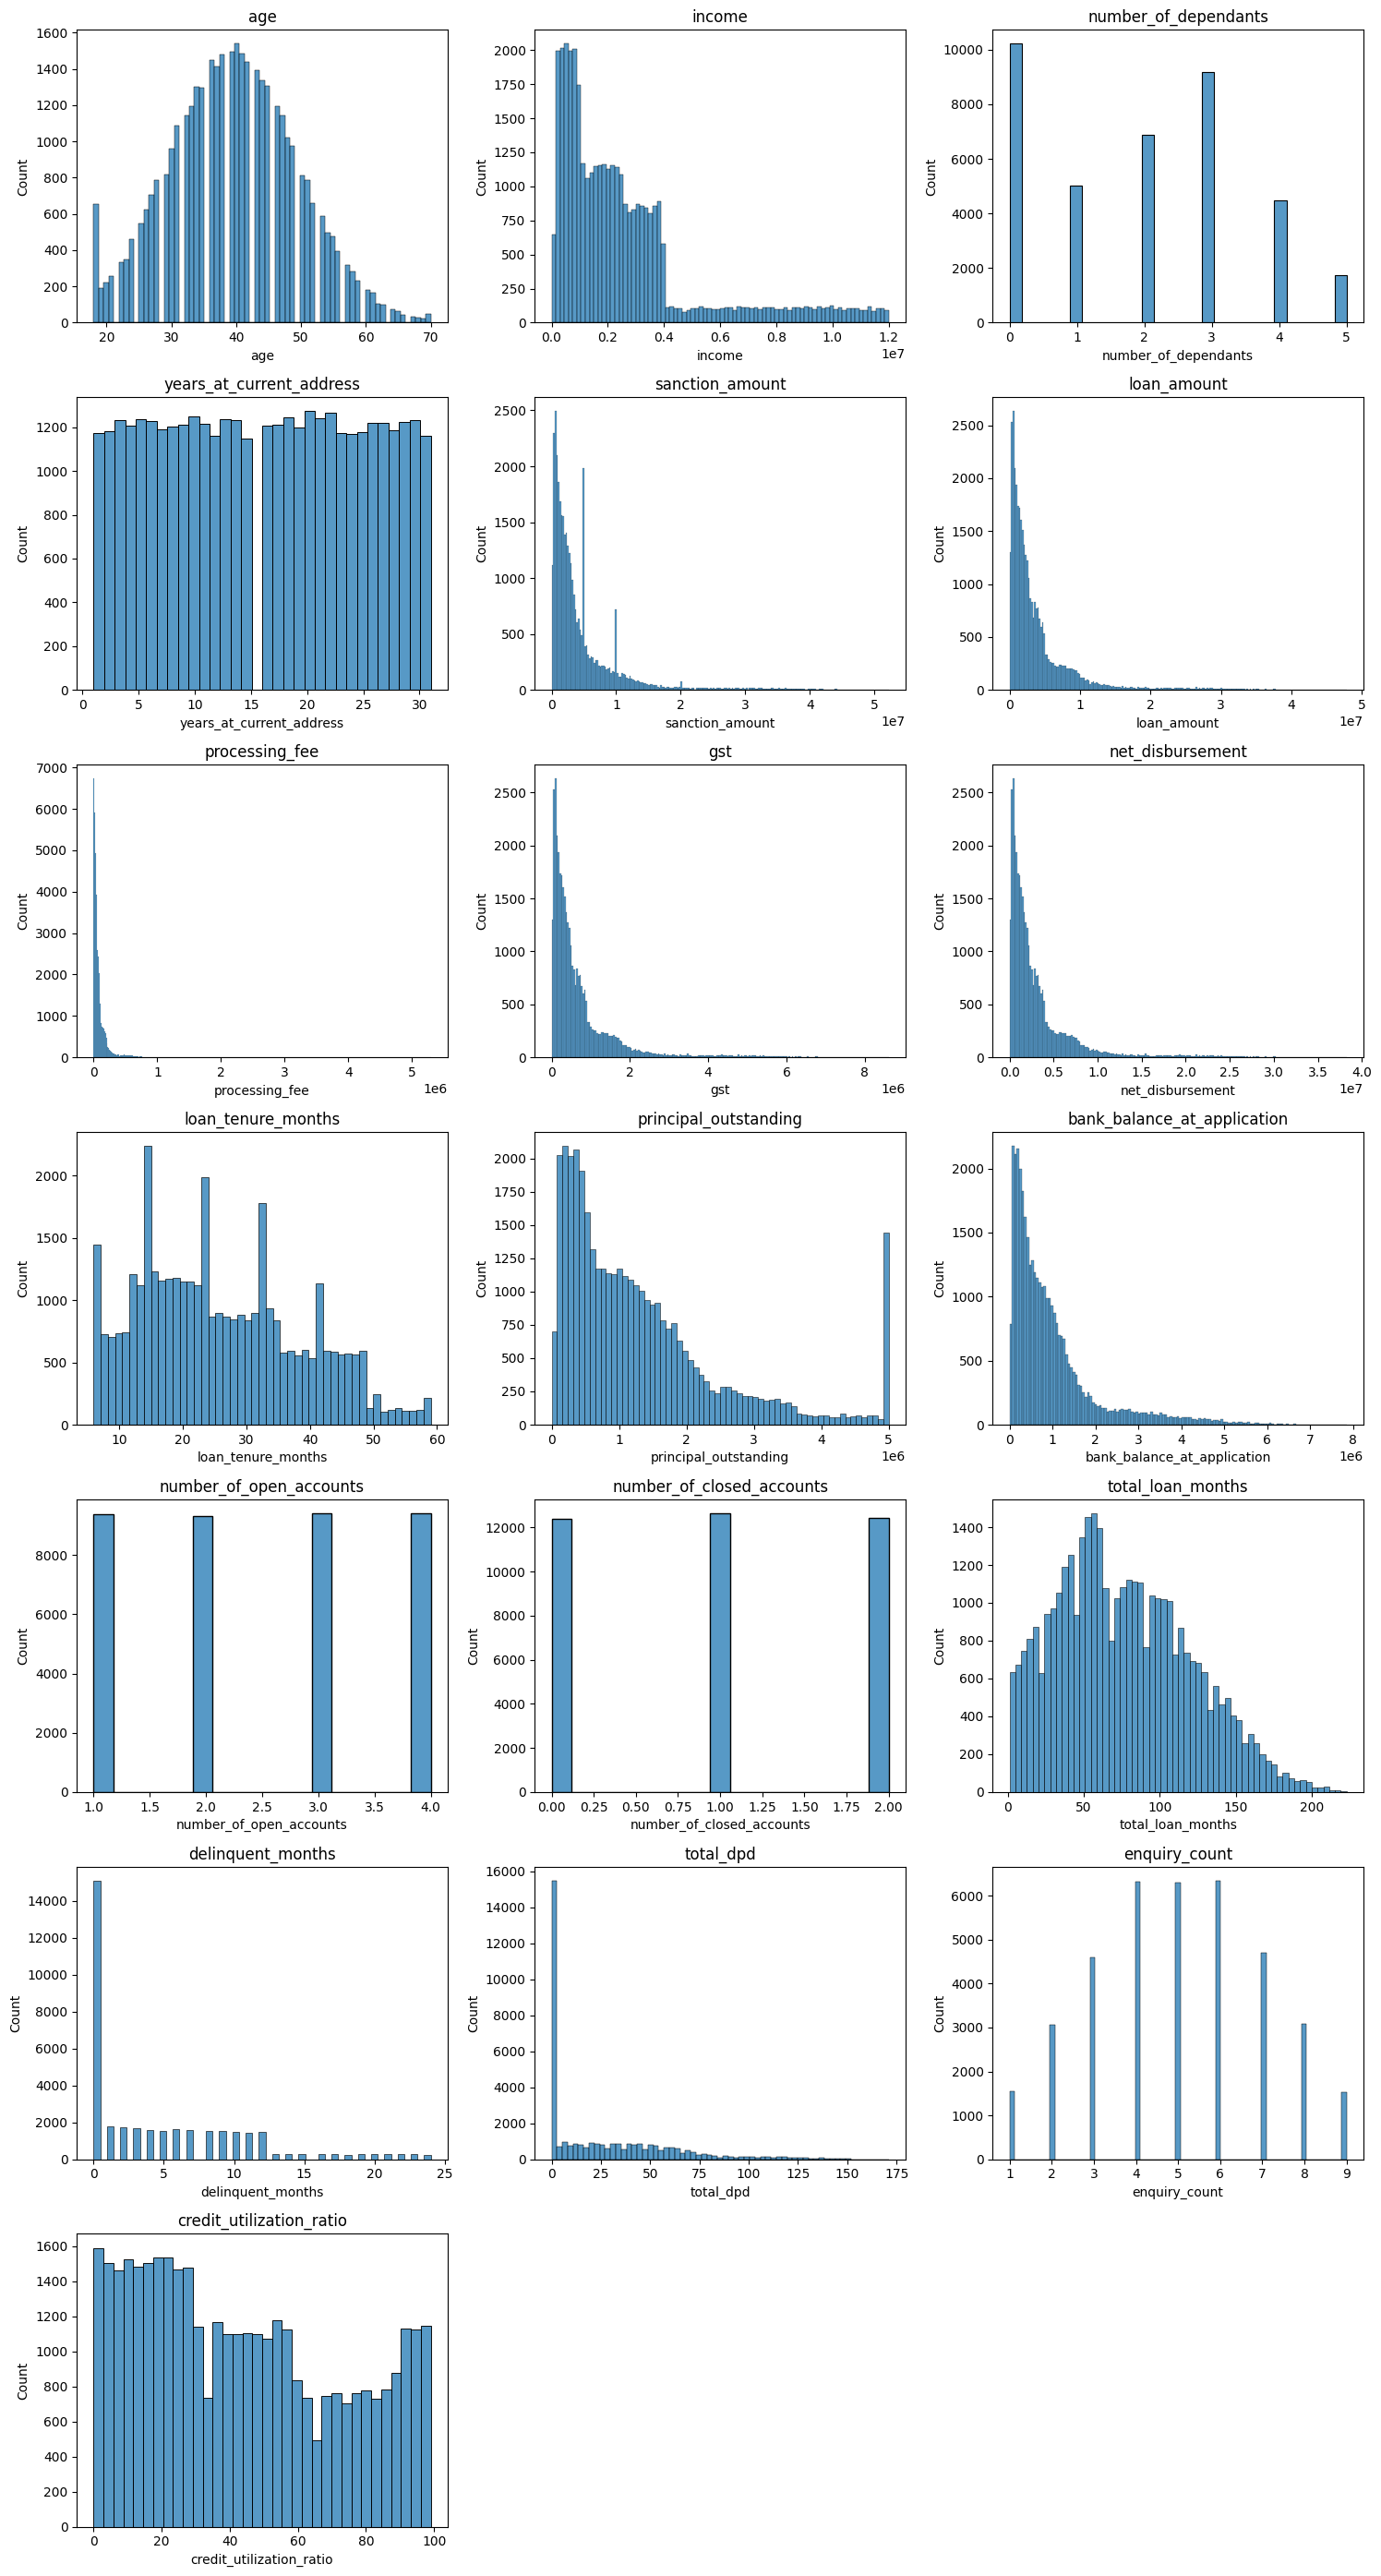

In [117]:
n_cols = 3
n_rows = (len(contd_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(contd_cols):
    sns.histplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

These columns naturally have right-skewed distributions in India:income, sanction_amount, loan_amount, net_disbursement
bank_balance_at_application, principal_outstanding,processing_fee, gst
processing_fee is extremely skewed so there might be an issue

In [118]:
df_train.processing_fee.describe()

count      37500.00
mean       80290.68
std       113128.14
min            0.00
25%        19220.00
50%        44600.00
75%        92420.00
max      5293543.52
Name: processing_fee, dtype: float64

### processing fee can never be greater than loan amount



In [119]:
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][["loan_amount","processing_fee"]]
#the ratio should always be less than 0.03(told by business poc)

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


In [120]:
df_train1 = df_train[(df_train.processing_fee/df_train.loan_amount)<0.03].copy()
df_test1 = df_test[(df_test.processing_fee/df_test.loan_amount)<0.03].copy()

In [121]:
for col in categ_cols:
    print(col, "-->",df_train[col].unique())

gender --> <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
marital_status --> <ArrowStringArray>
['Married', 'Single']
Length: 2, dtype: str
employment_status --> <ArrowStringArray>
['Self-Employed', 'Salaried']
Length: 2, dtype: str
residence_type --> <ArrowStringArray>
['Owned', 'Mortgage', 'Rented', nan]
Length: 4, dtype: str
city --> <ArrowStringArray>
['Hyderabad',    'Mumbai',   'Chennai', 'Bangalore',      'Pune',   'Kolkata',
 'Ahmedabad',     'Delhi',   'Lucknow',    'Jaipur']
Length: 10, dtype: str
state --> <ArrowStringArray>
[    'Telangana',   'Maharashtra',    'Tamil Nadu',     'Karnataka',
   'West Bengal',       'Gujarat',         'Delhi', 'Uttar Pradesh',
     'Rajasthan']
Length: 9, dtype: str
loan_purpose --> <ArrowStringArray>
['Home', 'Education', 'Personal', 'Auto', 'Personaal']
Length: 5, dtype: str
loan_type --> <ArrowStringArray>
['Secured', 'Unsecured']
Length: 2, dtype: str
default --> [0 1]


loan_purpose --> <ArrowStringArray>
['Home', 'Education', 'Personal', 'Auto', 'Personaal'] (personaal is just a wrong spelling)

In [122]:
df_train1['loan_purpose'] = df_train1['loan_purpose'].replace('personaal','personal')
df_test1['loan_purpose'] = df_test1['loan_purpose'].replace('personaal','personal')


### Exploratory Data Analytics

In [123]:
df_train1[(df_train1.gst/df_train1.loan_amount )>0.2]
##gst not more than  20%

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


<Axes: xlabel='age', ylabel='Density'>

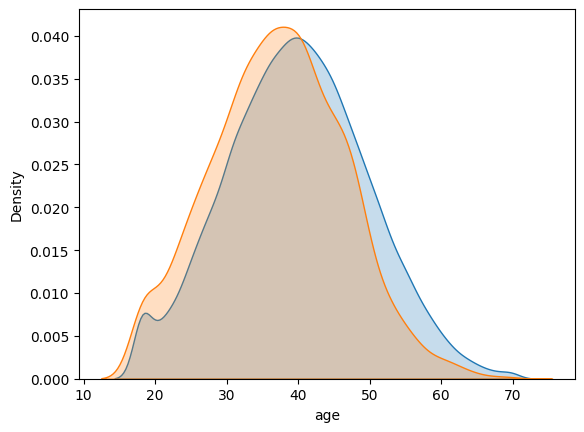

In [124]:
sns.kdeplot(df_train1[df_train1.default== 0]['age'], fill = True, label= "Default 0")
sns.kdeplot(df_train1[df_train1.default== 1]['age'], fill = True, label= "Default 1")

Orange graph shifted little bit the left of blue graph meaning the young people are more likely to default

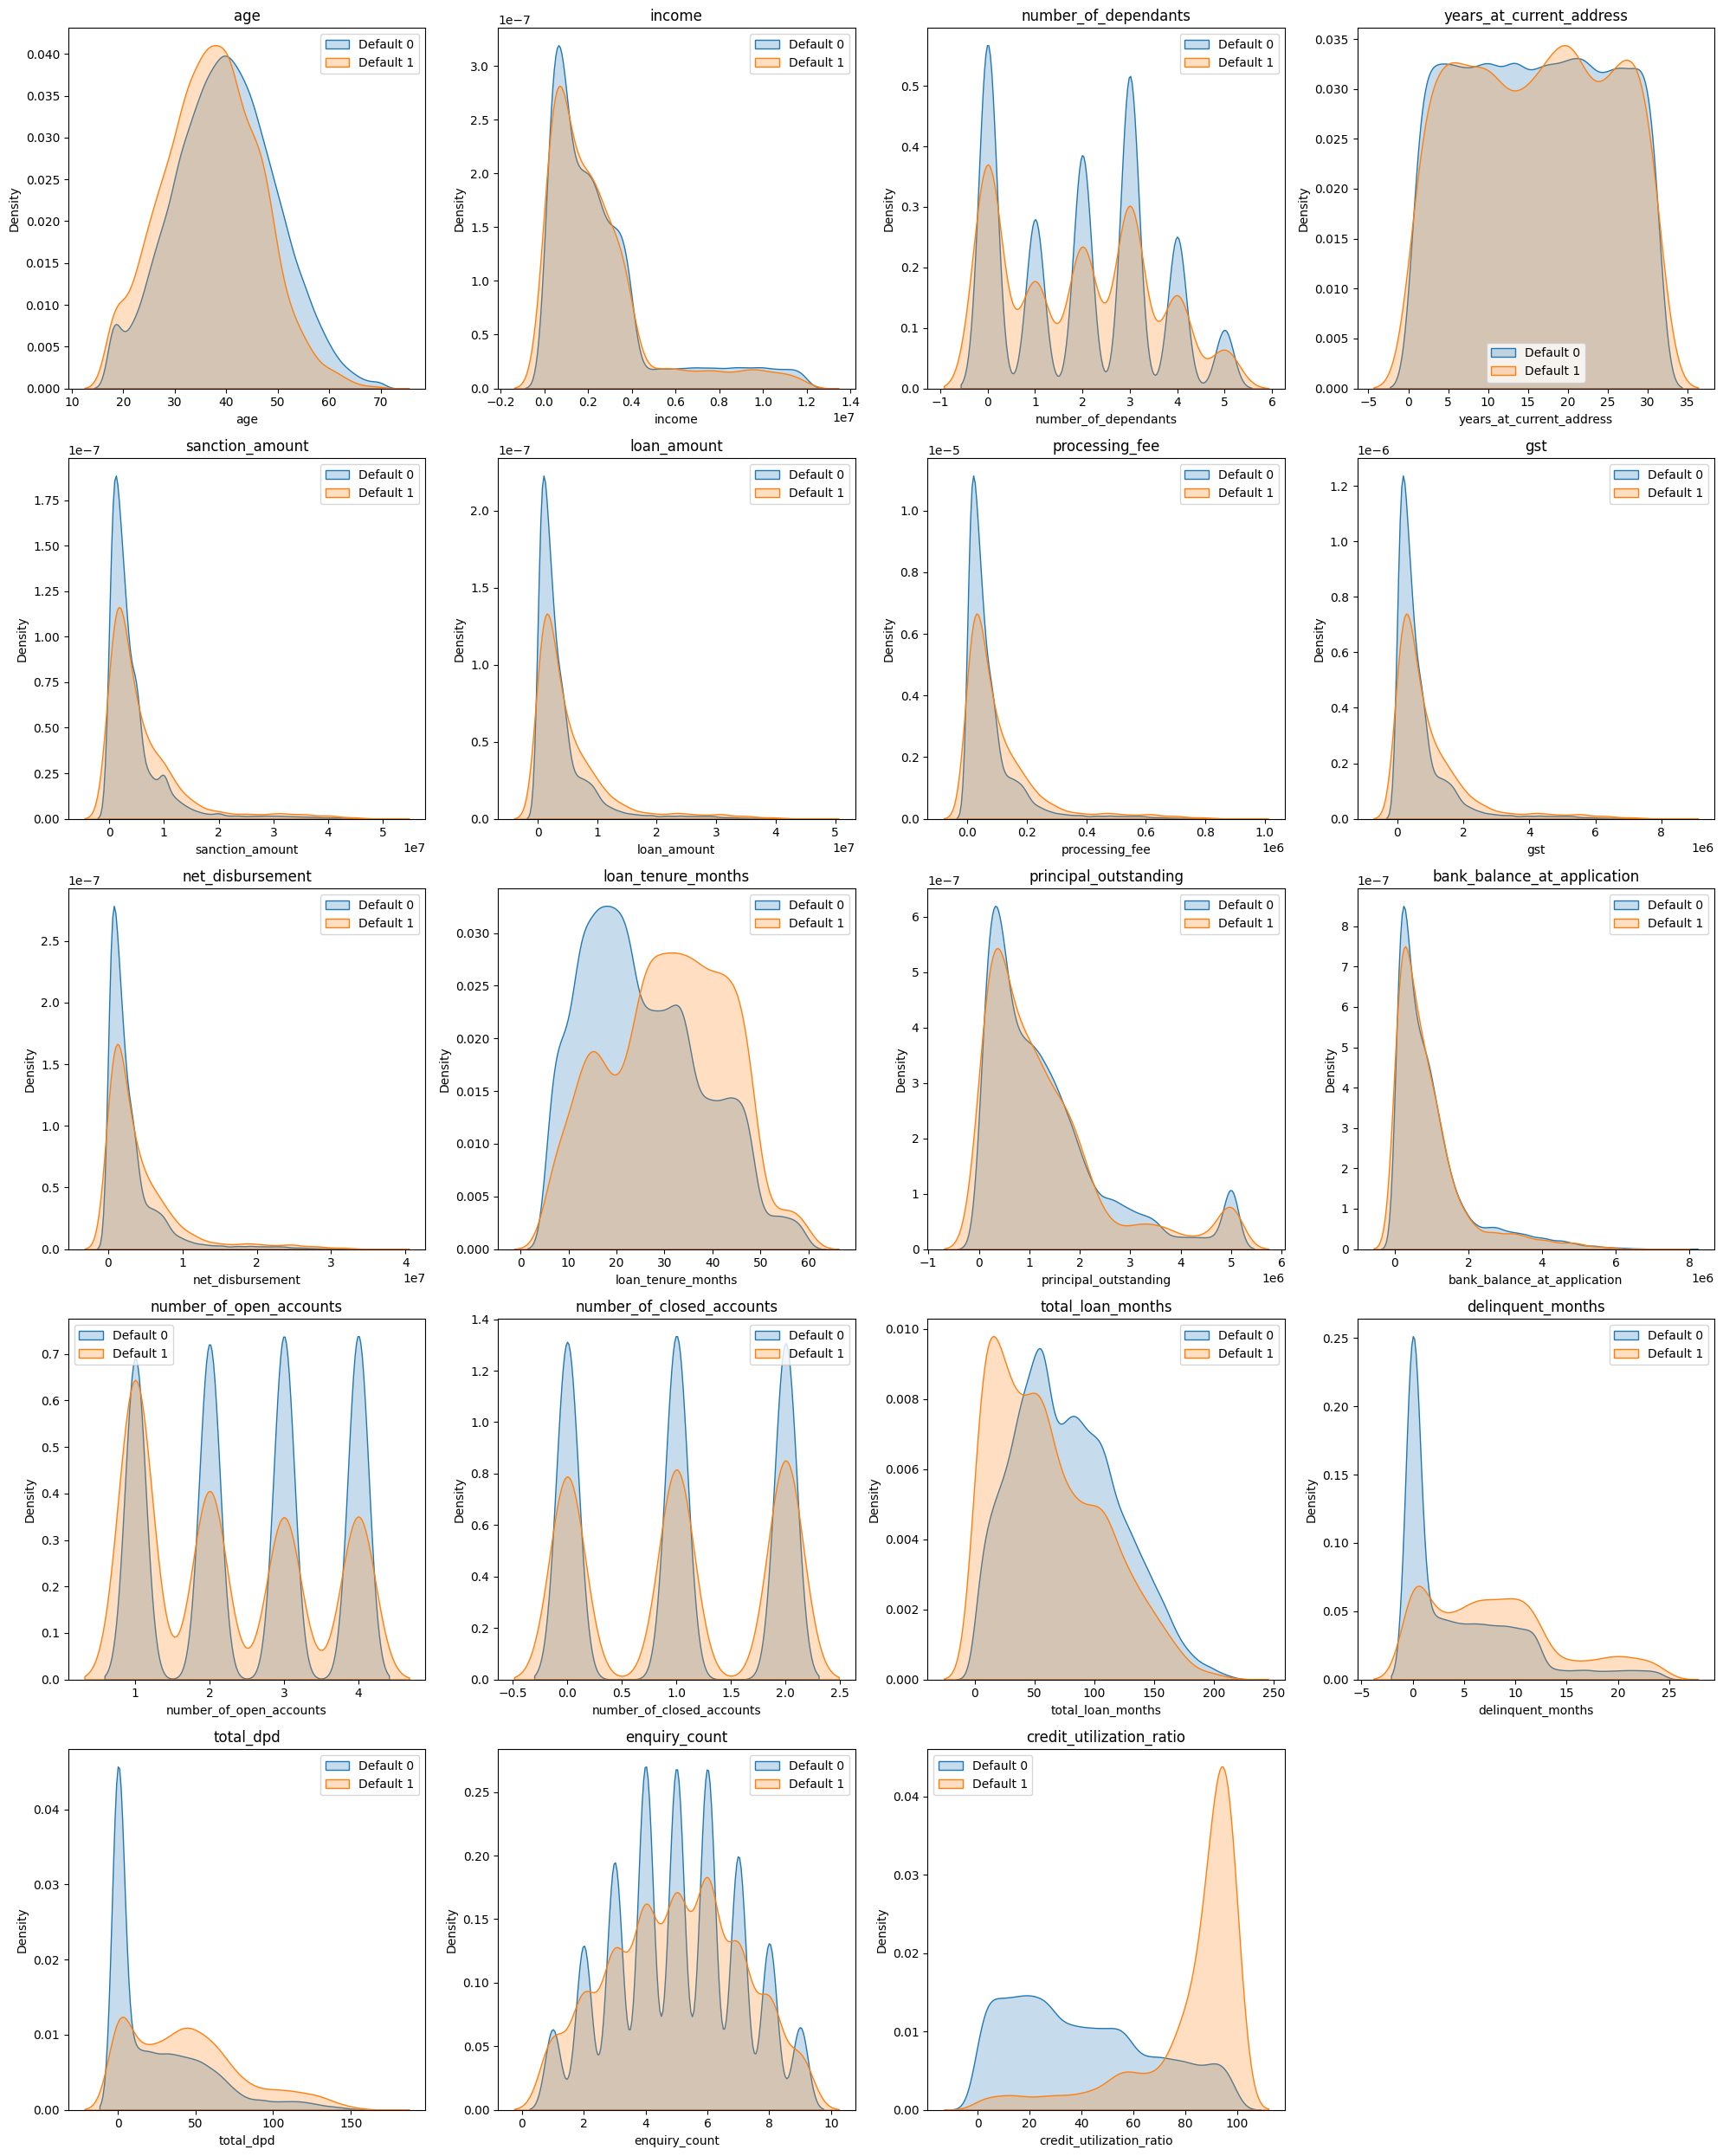

In [125]:
import math

n_cols = 4
n_rows = math.ceil(len(contd_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(contd_cols):
    sns.kdeplot(
        data=df_train1[df_train1['default'] == 0],
        x=col,
        fill=True,
        label='Default 0',
        ax=axes[i]
    )

    sns.kdeplot(
        data=df_train1[df_train1['default'] == 1],
        x=col,
        fill=True,
        label='Default 1',
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].legend()

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

 Age: Defaulters tend to be slightly younger than non-defaulters, indicating age may have a mild influence on repayment behavior.

Credit Utilization Ratio: Customers with high credit utilization (80-100%) are significantly more likely to default.

 Delinquent Months: Defaulters have substantially more delinquent months, making past repayment issues a strong risk indicator.

Total DPD: Higher Days Past Due (DPD) values are strongly associated with default behavior.

 Loan Tenure Months: Customers with longer loan tenures appear to have a higher likelihood of default.

 Total Loan Months: Non-defaulters generally have a longer credit history, suggesting experienced borrowers are less risky.

Enquiry Count: Defaulters tend to have slightly higher credit enquiry counts, indicating possible credit-seeking behavior.

 Income: Income distributions are very similar across both classes, suggesting income alone is not a strong predictor of default.

 Sanction Amount, Loan Amount, Net Disbursement, Processing Fee, GST, Principal Outstanding, and Bank Balance: These features show substantial overlap between defaulters and non-defaulters and provide limited individual discriminatory power.

Number of Dependants, Years at Current Address, Number of Open Accounts, and Number of Closed Accounts: These variables exhibit minimal separation between classes and appear to have a weak standalone relationship with default.

### Feature Engineering

In [126]:
df_train1["loan_income_ratio"] = round(df_train1["loan_amount"]/ df_train1["income"], 2)
df_test1['loan_income_ratio'] = round(df_test1['loan_amount'] / df_test1['income'],2)

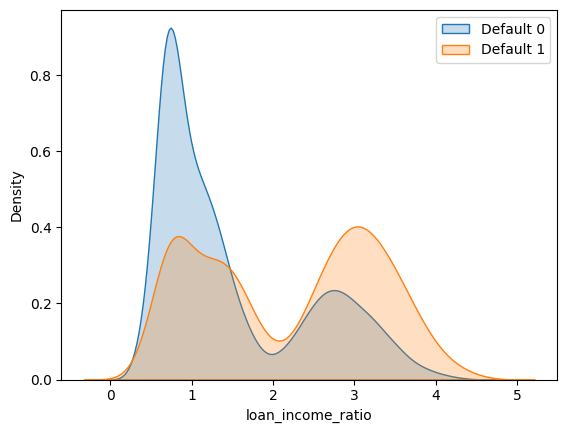

In [127]:
sns.kdeplot(df_train1[df_train1.default==0]["loan_income_ratio"], fill =True, label = "Default 0")
sns.kdeplot(df_train1[df_train1.default==1]["loan_income_ratio"], fill =True, label = "Default 1")
plt.legend()

those who have lower loan to income ratio(0 to 2), they are less likely to default( a high density peak) applicants with a ratio above 2.0 represent a higher risk profile while those around 1.0 are generally safer for lending

In [128]:
df_train1["delinquency_ratio"] = round(df_train1['delinquent_months']*100/ df_train1["total_loan_months"],1)
df_test1["delinquency_ratio"] = round(df_test1['delinquent_months']*100/ df_test1["total_loan_months"],1)


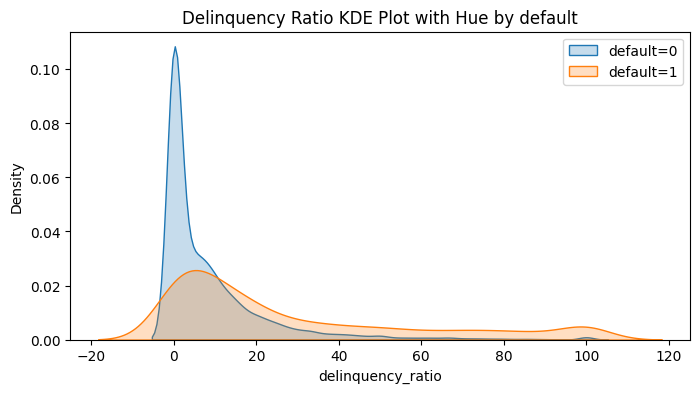

In [129]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train1['delinquency_ratio'][df_train1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train1['delinquency_ratio'][df_train1['default'] == 1], fill=True, label='default=1')
plt.title(f"Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

people with less delinquency ratio are less likely to default

#### Generate Avg DPD Per Delinquency

In [130]:
df_train1['avg_dpd_per_delinquency'] = np.where(
    df_train1['delinquent_months'] != 0,
    (df_train1['total_dpd'] / df_train1['delinquent_months']).round(1),
    0
)

df_test1['avg_dpd_per_delinquency'] = np.where(
    df_test1['delinquent_months'] != 0,
    (df_test1['total_dpd'] / df_test1['delinquent_months']).round(1),
    0
)

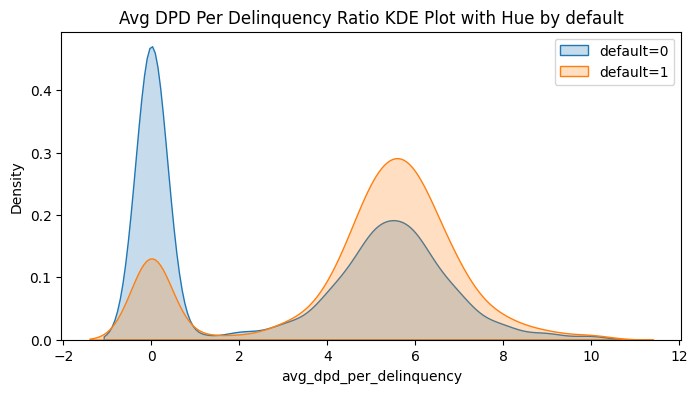

In [131]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train1['avg_dpd_per_delinquency'][df_train1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train1['avg_dpd_per_delinquency'][df_train1['default'] == 1], fill=True, label='default=1')
plt.title(f"Avg DPD Per Delinquency Ratio KDE Plot with Hue by default")
plt.legend()
plt.show()

**Insights**

1. Graph clearly shows more occurances of default cases when avg_dpd_per_delinquency is high. This means this column is a strong predictor

### Feature Selection

Remove unnecessary columns

In [132]:
df_train2 = df_train1.drop(['cust_id', 'loan_id'],axis="columns")
df_test1 = df_test1.drop(['cust_id', 'loan_id'],axis="columns")

### Remove columns that are just unique ids and don't have influence on target

In [133]:
df_train3 = df_train2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_test1 = df_test1.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns")
df_train3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_income_ratio',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='str')

### Check for collinearity

In [134]:
df_train3.select_dtypes(["int64", "float64"]).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_income_ratio',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='str')

In [135]:
X_train= df_train3.drop('default', axis= 'columns')
y_train= df_train3['default'] 
#Zipcode is a categorical column so no need to scale
from sklearn.preprocessing import MinMaxScaler
cols_to_scale = ['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_income_ratio',
       'delinquency_ratio', 'avg_dpd_per_delinquency']

scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])



In [136]:
X_test= df_test1.drop('default', axis= 'columns')
y_test= df_test1['default']

X_test[cols_to_scale] = scaler.fit_transform(X_test[cols_to_scale])

### VIF to measure collinearity

In [137]:
#same VIF function as used before

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [138]:
calculate_vif(X_train[cols_to_scale])

C:\Users\KIIT\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.55
1,number_of_dependants,2.72
2,years_at_current_address,3.36
3,sanction_amount,101.08
4,processing_fee,inf
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,6.17
8,principal_outstanding,16.32
9,bank_balance_at_application,9.33


processing_fee, gst, net_disbursement, sanction_amount, principal_outstanding these are all those columns which have inf or high collinearity

In [139]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

In [140]:
calculate_vif(X_train_1[numeric_columns])

,Column,VIF
0,age,5.53
1,number_of_dependants,2.73
2,years_at_current_address,3.45
3,zipcode,5.61
4,loan_tenure_months,6.03
5,bank_balance_at_application,1.81
6,number_of_open_accounts,4.36
7,number_of_closed_accounts,2.39
8,enquiry_count,6.44
9,credit_utilization_ratio,2.95


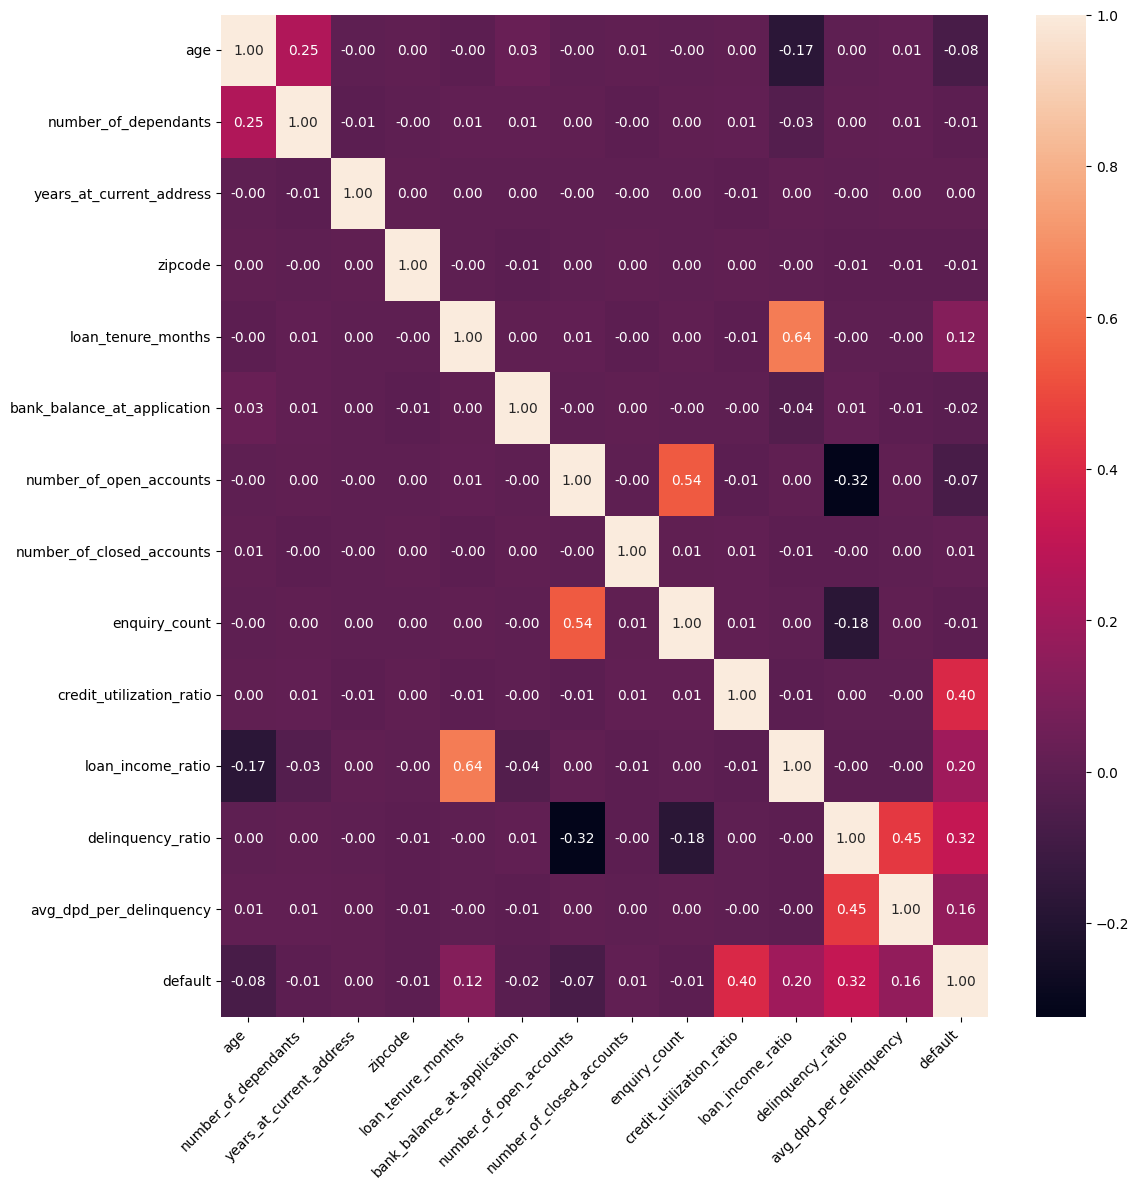

In [141]:
plt.figure(figsize=(12,12))
cm = df_train3[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Analysis if Categorical columns using WOE and IV (used mostly for credit risk modeling)

In [142]:
categ_cols

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'loan_purpose',
 'loan_type',
 'default']

In [143]:
temp = pd.concat([X_train_1, y_train], axis = 1)
temp.groupby('loan_purpose')['default'].agg(['count', 'sum'])

,count,sum
loan_purpose,,
Auto,7447,327
Education,5620,559
Home,11304,1734
Personaal,18,1
Personal,13099,602


In [144]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    # 1- good , 0- bad
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0) #handle infinite values
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,0.08
Education,5620,559,5061,0.17,0.15,0.16,0.00
Home,11304,1734,9570,0.54,0.28,0.66,0.17
Personaal,18,1,17,0.00,0.00,-0.47,0.00
Personal,13099,602,12497,0.19,0.36,-0.67,0.12


IV for categrorical columns can be calculated normally but for continuous columns we need to use pd.cut() function

In [145]:


iv_values = {}

# Combine X and y once
df_iv = pd.concat([X_train_1, y_train], axis=1)

# Identify categorical and numerical columns
cat_cols = X_train_1.select_dtypes(
    include=['object', 'string', 'category']
).columns

num_cols = X_train_1.select_dtypes(
    include=['number']
).columns

# Calculate IV for categorical features
for feature in cat_cols:

    _, iv = calculate_woe_iv(
        df_iv,
        feature,
        'default'
    )

    iv_values[feature] = iv

# Calculate IV for numerical features
for feature in num_cols:

    try:
        # Bin numeric variable into 10 buckets
        binned_feature = pd.cut(
            X_train_1[feature],
            bins=10,
            labels=False,
            duplicates='drop'
        )

        temp_df = pd.DataFrame({
            feature: binned_feature,
            'default': y_train
        })

        _, iv = calculate_woe_iv(
            temp_df,
            feature,
            'default'
        )

        iv_values[feature] = iv

    except Exception as e:
        print(f"Error in {feature}: {e}")

# Create IV table
iv_df = pd.DataFrame(
    list(iv_values.items()),
    columns=['Feature', 'IV']
)

iv_df = iv_df.sort_values(
    by='IV',
    ascending=False
).reset_index(drop=True)

print(iv_df)

                        Feature    IV
0      credit_utilization_ratio  2.35
1             delinquency_ratio  0.72
2             loan_income_ratio  0.48
3       avg_dpd_per_delinquency  0.40
4                  loan_purpose  0.37
5                residence_type  0.25
6            loan_tenure_months  0.22
7                     loan_type  0.16
8                           age  0.09
9       number_of_open_accounts  0.08
10                enquiry_count  0.01
11  bank_balance_at_application  0.01
12            employment_status  0.00
13     years_at_current_address  0.00
14         number_of_dependants  0.00
15                         city  0.00
16                        state  0.00
17                      zipcode  0.00
18    number_of_closed_accounts  0.00
19               marital_status  0.00
20                       gender  0.00


### Feature Encoding

In [146]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['residence_type',
 'loan_purpose',
 'loan_type',
 'age',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_income_ratio',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

Keep those whose IV>0.02

In [147]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [160]:
X_train_reduced['loan_purpose'] = X_train_reduced['loan_purpose'].replace(
    'Personaal',
    'Personal'
)

X_test_reduced['loan_purpose'] = X_test_reduced['loan_purpose'].replace(
    'Personaal',
    'Personal'
)

One Hot Encoding

In [161]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)
X_train_encoded.head(3)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_income_ratio,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.79,0.42,1.00,0.36,0.41,0.13,0.59,True,False,False,True,False,False
32495,0.50,0.83,0.67,0.05,0.31,0.06,0.62,True,False,True,False,False,False
43675,0.38,0.49,0.00,0.00,0.76,0.22,0.56,False,False,False,True,False,False


In [162]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='str')

### Model Training and evaluation

### Logistic Regression

In [164]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.71      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



precision for both 0 and 1 are good but recall for 1 is <90. our requirement is high recall

### XGBoost Classifier

In [165]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.75      0.79      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.96      0.96     12497



similar results

### Randomized Search CV using LR

In [166]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'lbfgs', 'C': np.float64(1438.44988828766)}
Best Score: 0.7589807050091197
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.84      0.73      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



Still the recall for 1 is not high

### Randomized Search CV using XGBoost


In [167]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 10.0, 'reg_alpha': 10.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best Score: 0.7876295983289688
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.78      0.82      0.80      1074

    accuracy                           0.97     12497
   macro avg       0.88      0.90      0.89     12497
weighted avg       0.97      0.97      0.97     12497



For XGBoost also, the recall is less than 90%

### Model Trainging after removal of class imbalance

Undersampling: 

In [168]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state= 42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_encoded, y_train)
y_train_rus.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

class imbalance removed

In [169]:
model = LogisticRegression()
model. fit(X_train_rus, y_train_rus)
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.95      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.93      0.81     12497
weighted avg       0.95      0.92      0.93     12497



Now we got high precision for both the classes (its said that precison>50 is okay)

Oversampling Logistic Regression &Handle Class Imbalance Using SMOTE Tomek

In [170]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34194
1    34194
Name: count, dtype: int64

In [171]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



we have a better recall and precison is as per required

### Model Fine Tuning using Optuna

macro_avg = average of f1 scores

In [172]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [174]:

def objective(trial):

    solver = trial.suggest_categorical(
        'solver',
        ['liblinear', 'saga']
    )

    penalty = trial.suggest_categorical(
        'penalty',
        ['l1', 'l2']
    )

    C = trial.suggest_float(
        'C',
        1e-4,
        100,
        log=True
    )

    class_weight = trial.suggest_categorical(
        'class_weight',
        [None, 'balanced']
    )

    max_iter = trial.suggest_int(
        'max_iter',
        100,
        5000
    )

    model = LogisticRegression(
        solver=solver,
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        max_iter=max_iter,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_encoded,
        y_train,
        cv=5,
        scoring='roc_auc', #preferably use f1
        n_jobs=-1
    ).mean()

    return np.mean(score)
study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-06-26 03:02:27,006] A new study created in memory with name: no-name-b2eddca1-229b-48fc-9bce-b5f55d932038
Best trial: 0. Best value: 0.982622:   2%|▏         | 1/50 [00:05<04:14,  5.20s/it]

[I 2026-06-26 03:02:32,203] Trial 0 finished with value: 0.982622313726969 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.9044980316523383, 'class_weight': 'balanced', 'max_iter': 4176}. Best is trial 0 with value: 0.982622313726969.


Best trial: 1. Best value: 0.982679:   4%|▍         | 2/50 [00:10<04:07,  5.15s/it]

[I 2026-06-26 03:02:37,321] Trial 1 finished with value: 0.9826788876919285 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 9.137010412126545, 'class_weight': None, 'max_iter': 4890}. Best is trial 1 with value: 0.9826788876919285.


Best trial: 2. Best value: 0.98268:   6%|▌         | 3/50 [00:12<03:06,  3.98s/it] 

[I 2026-06-26 03:02:39,900] Trial 2 finished with value: 0.9826801142784017 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 10.710853592373416, 'class_weight': None, 'max_iter': 4016}. Best is trial 2 with value: 0.9826801142784017.


Best trial: 3. Best value: 0.98268:  10%|█         | 5/50 [00:15<01:37,  2.16s/it]

[I 2026-06-26 03:02:42,143] Trial 3 finished with value: 0.9826802499490673 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 18.56054892776161, 'class_weight': None, 'max_iter': 3303}. Best is trial 3 with value: 0.9826802499490673.
[I 2026-06-26 03:02:42,299] Trial 4 finished with value: 0.9469339170811384 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.0011618679323416624, 'class_weight': 'balanced', 'max_iter': 1155}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  14%|█▍        | 7/50 [00:15<00:45,  1.05s/it]

[I 2026-06-26 03:02:42,472] Trial 5 finished with value: 0.9816268646100974 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.25114900245957994, 'class_weight': None, 'max_iter': 3697}. Best is trial 3 with value: 0.9826802499490673.
[I 2026-06-26 03:02:42,617] Trial 6 finished with value: 0.9785363736883586 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.04032552373399048, 'class_weight': 'balanced', 'max_iter': 1747}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  16%|█▌        | 8/50 [00:15<00:32,  1.31it/s]

[I 2026-06-26 03:02:42,773] Trial 7 finished with value: 0.9807961761697153 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.2525396140362082, 'class_weight': None, 'max_iter': 3264}. Best is trial 3 with value: 0.9826802499490673.
[I 2026-06-26 03:02:42,872] Trial 8 finished with value: 0.816748271201965 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.001208279902043819, 'class_weight': None, 'max_iter': 3868}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  20%|██        | 10/50 [00:16<00:18,  2.17it/s]

[I 2026-06-26 03:02:43,032] Trial 9 finished with value: 0.8732213004884137 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.00011839179119325232, 'class_weight': None, 'max_iter': 1754}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  24%|██▍       | 12/50 [00:16<00:14,  2.67it/s]

[I 2026-06-26 03:02:43,441] Trial 10 finished with value: 0.9814109544064571 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.01832666125984999, 'class_weight': 'balanced', 'max_iter': 174}. Best is trial 3 with value: 0.9826802499490673.
[I 2026-06-26 03:02:43,613] Trial 11 finished with value: 0.9826787072661028 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 83.98227792663673, 'class_weight': None, 'max_iter': 2748}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  28%|██▊       | 14/50 [00:16<00:09,  3.61it/s]

[I 2026-06-26 03:02:43,790] Trial 12 finished with value: 0.9826787075471399 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 23.333263868999882, 'class_weight': None, 'max_iter': 2683}. Best is trial 3 with value: 0.9826802499490673.
[I 2026-06-26 03:02:43,957] Trial 13 finished with value: 0.9826630551149538 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 3.883743852865184, 'class_weight': None, 'max_iter': 4883}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  30%|███       | 15/50 [00:19<00:29,  1.21it/s]

[I 2026-06-26 03:02:46,154] Trial 14 finished with value: 0.9826787971979785 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 51.74465538011943, 'class_weight': None, 'max_iter': 2944}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 3. Best value: 0.98268:  32%|███▏      | 16/50 [00:19<00:22,  1.51it/s]

[I 2026-06-26 03:02:46,412] Trial 15 finished with value: 0.9826268881680333 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 2.405196098141897, 'class_weight': None, 'max_iter': 4309}. Best is trial 3 with value: 0.9826802499490673.


Best trial: 16. Best value: 0.982681:  34%|███▍      | 17/50 [00:19<00:17,  1.86it/s]

[I 2026-06-26 03:02:46,650] Trial 16 finished with value: 0.9826807480170882 and parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 11.023189147258963, 'class_weight': None, 'max_iter': 2185}. Best is trial 16 with value: 0.9826807480170882.


Best trial: 16. Best value: 0.982681:  36%|███▌      | 18/50 [00:19<00:14,  2.26it/s]

[I 2026-06-26 03:02:46,868] Trial 17 finished with value: 0.9822548288270754 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.8891010903668332, 'class_weight': None, 'max_iter': 2138}. Best is trial 16 with value: 0.9826807480170882.


Best trial: 18. Best value: 0.982747:  38%|███▊      | 19/50 [00:20<00:16,  1.89it/s]

[I 2026-06-26 03:02:47,596] Trial 18 finished with value: 0.9827469374560408 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 19.846414850674137, 'class_weight': 'balanced', 'max_iter': 818}. Best is trial 18 with value: 0.9827469374560408.


Best trial: 19. Best value: 0.982747:  40%|████      | 20/50 [00:21<00:17,  1.69it/s]

[I 2026-06-26 03:02:48,345] Trial 19 finished with value: 0.9827470283012871 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 86.27186870209135, 'class_weight': 'balanced', 'max_iter': 509}. Best is trial 19 with value: 0.9827470283012871.


Best trial: 19. Best value: 0.982747:  42%|████▏     | 21/50 [00:22<00:18,  1.59it/s]

[I 2026-06-26 03:02:49,057] Trial 20 finished with value: 0.9827468018556346 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 98.84179360617554, 'class_weight': 'balanced', 'max_iter': 209}. Best is trial 19 with value: 0.9827470283012871.


Best trial: 19. Best value: 0.982747:  44%|████▍     | 22/50 [00:22<00:18,  1.52it/s]

[I 2026-06-26 03:02:49,778] Trial 21 finished with value: 0.9827468924198438 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 96.66459058771126, 'class_weight': 'balanced', 'max_iter': 148}. Best is trial 19 with value: 0.9827470283012871.


Best trial: 22. Best value: 0.982747:  46%|████▌     | 23/50 [00:23<00:18,  1.44it/s]

[I 2026-06-26 03:02:50,559] Trial 22 finished with value: 0.9827474807710368 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 35.6843956065029, 'class_weight': 'balanced', 'max_iter': 752}. Best is trial 22 with value: 0.9827474807710368.


Best trial: 23. Best value: 0.982748:  48%|████▊     | 24/50 [00:24<00:18,  1.44it/s]

[I 2026-06-26 03:02:51,261] Trial 23 finished with value: 0.9827484327139928 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 3.2278228054946174, 'class_weight': 'balanced', 'max_iter': 797}. Best is trial 23 with value: 0.9827484327139928.


Best trial: 23. Best value: 0.982748:  50%|█████     | 25/50 [00:24<00:17,  1.43it/s]

[I 2026-06-26 03:02:51,967] Trial 24 finished with value: 0.9827475274934567 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 3.5235319083738923, 'class_weight': 'balanced', 'max_iter': 926}. Best is trial 23 with value: 0.9827484327139928.


Best trial: 25. Best value: 0.982749:  52%|█████▏    | 26/50 [00:25<00:17,  1.40it/s]

[I 2026-06-26 03:02:52,709] Trial 25 finished with value: 0.9827489314143472 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 2.488931140143044, 'class_weight': 'balanced', 'max_iter': 1135}. Best is trial 25 with value: 0.9827489314143472.


Best trial: 26. Best value: 0.98275:  54%|█████▍    | 27/50 [00:26<00:16,  1.40it/s] 

[I 2026-06-26 03:02:53,434] Trial 26 finished with value: 0.9827496562793172 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 2.3118543849720705, 'class_weight': 'balanced', 'max_iter': 1360}. Best is trial 26 with value: 0.9827496562793172.


Best trial: 27. Best value: 0.982764:  56%|█████▌    | 28/50 [00:27<00:15,  1.42it/s]

[I 2026-06-26 03:02:54,105] Trial 27 finished with value: 0.9827642025494324 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.34000692531991655, 'class_weight': 'balanced', 'max_iter': 1456}. Best is trial 27 with value: 0.9827642025494324.


Best trial: 27. Best value: 0.982764:  58%|█████▊    | 29/50 [00:27<00:14,  1.43it/s]

[I 2026-06-26 03:02:54,793] Trial 28 finished with value: 0.9827232999866642 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.10776140620800902, 'class_weight': 'balanced', 'max_iter': 1426}. Best is trial 27 with value: 0.9827642025494324.


Best trial: 27. Best value: 0.982764:  60%|██████    | 30/50 [00:28<00:13,  1.43it/s]

[I 2026-06-26 03:02:55,490] Trial 29 finished with value: 0.9827527415749868 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.7738824099146797, 'class_weight': 'balanced', 'max_iter': 1357}. Best is trial 27 with value: 0.9827642025494324.


Best trial: 27. Best value: 0.982764:  62%|██████▏   | 31/50 [00:29<00:12,  1.47it/s]

[I 2026-06-26 03:02:56,135] Trial 30 finished with value: 0.982753285452057 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.6690205771743525, 'class_weight': 'balanced', 'max_iter': 2220}. Best is trial 27 with value: 0.9827642025494324.


Best trial: 27. Best value: 0.982764:  64%|██████▍   | 32/50 [00:29<00:12,  1.50it/s]

[I 2026-06-26 03:02:56,772] Trial 31 finished with value: 0.9827528322797147 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.7624849712916493, 'class_weight': 'balanced', 'max_iter': 2030}. Best is trial 27 with value: 0.9827642025494324.


Best trial: 27. Best value: 0.982764:  66%|██████▌   | 33/50 [00:30<00:11,  1.50it/s]

[I 2026-06-26 03:02:57,435] Trial 32 finished with value: 0.9827533308395505 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.7006934795627072, 'class_weight': 'balanced', 'max_iter': 2203}. Best is trial 27 with value: 0.9827642025494324.


Best trial: 33. Best value: 0.982765:  68%|██████▊   | 34/50 [00:31<00:10,  1.56it/s]

[I 2026-06-26 03:02:58,012] Trial 33 finished with value: 0.9827646165170977 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.27854481386581614, 'class_weight': 'balanced', 'max_iter': 2293}. Best is trial 33 with value: 0.9827646165170977.


Best trial: 34. Best value: 0.982765:  70%|███████   | 35/50 [00:31<00:09,  1.56it/s]

[I 2026-06-26 03:02:58,657] Trial 34 finished with value: 0.9827653823432266 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.30269229587106516, 'class_weight': 'balanced', 'max_iter': 2478}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  72%|███████▏  | 36/50 [00:32<00:08,  1.56it/s]

[I 2026-06-26 03:02:59,297] Trial 35 finished with value: 0.98235842170598 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.04327725664532319, 'class_weight': 'balanced', 'max_iter': 2457}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  74%|███████▍  | 37/50 [00:32<00:08,  1.60it/s]

[I 2026-06-26 03:02:59,889] Trial 36 finished with value: 0.9827637104534499 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.2685510481875539, 'class_weight': 'balanced', 'max_iter': 1818}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  76%|███████▌  | 38/50 [00:33<00:07,  1.61it/s]

[I 2026-06-26 03:03:00,493] Trial 37 finished with value: 0.9827421284192475 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.1367562791875033, 'class_weight': 'balanced', 'max_iter': 1844}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  78%|███████▊  | 39/50 [00:33<00:06,  1.76it/s]

[I 2026-06-26 03:03:00,937] Trial 38 finished with value: 0.9792539519983133 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.0049460306908441125, 'class_weight': 'balanced', 'max_iter': 3146}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  80%|████████  | 40/50 [00:35<00:09,  1.04it/s]

[I 2026-06-26 03:03:02,816] Trial 39 finished with value: 0.9827604572381062 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.2547216777979673, 'class_weight': 'balanced', 'max_iter': 2474}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  82%|████████▏ | 41/50 [00:36<00:07,  1.15it/s]

[I 2026-06-26 03:03:03,461] Trial 40 finished with value: 0.9824077229223078 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.0458401276008828, 'class_weight': 'balanced', 'max_iter': 1573}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  84%|████████▍ | 42/50 [00:38<00:09,  1.18s/it]

[I 2026-06-26 03:03:05,369] Trial 41 finished with value: 0.9827607263311405 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.2704570339351418, 'class_weight': 'balanced', 'max_iter': 2588}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  86%|████████▌ | 43/50 [00:40<00:09,  1.37s/it]

[I 2026-06-26 03:03:07,194] Trial 42 finished with value: 0.9827579164518401 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.30598466118311857, 'class_weight': 'balanced', 'max_iter': 3532}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  88%|████████▊ | 44/50 [00:41<00:08,  1.39s/it]

[I 2026-06-26 03:03:08,632] Trial 43 finished with value: 0.9826354294479271 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.08999646265732739, 'class_weight': 'balanced', 'max_iter': 2558}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  90%|█████████ | 45/50 [00:42<00:05,  1.14s/it]

[I 2026-06-26 03:03:09,168] Trial 44 finished with value: 0.9807170956287157 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.016012230496092142, 'class_weight': 'balanced', 'max_iter': 1904}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  92%|█████████▏| 46/50 [00:43<00:05,  1.31s/it]

[I 2026-06-26 03:03:10,898] Trial 45 finished with value: 0.9827577764953584 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.3834945978067357, 'class_weight': 'balanced', 'max_iter': 2931}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  94%|█████████▍| 47/50 [00:45<00:03,  1.29s/it]

[I 2026-06-26 03:03:12,119] Trial 46 finished with value: 0.982738912441321 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1701743509998808, 'class_weight': 'balanced', 'max_iter': 1690}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  96%|█████████▌| 48/50 [00:45<00:02,  1.01s/it]

[I 2026-06-26 03:03:12,469] Trial 47 finished with value: 0.9807668458018293 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.017097153366325498, 'class_weight': 'balanced', 'max_iter': 2848}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765:  98%|█████████▊| 49/50 [00:45<00:00,  1.21it/s]

[I 2026-06-26 03:03:12,877] Trial 48 finished with value: 0.9826107175034136 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.06632328175112484, 'class_weight': 'balanced', 'max_iter': 2508}. Best is trial 34 with value: 0.9827653823432266.


Best trial: 34. Best value: 0.982765: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]

[I 2026-06-26 03:03:13,298] Trial 49 finished with value: 0.9827608046702354 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.3778744754023319, 'class_weight': 'balanced', 'max_iter': 3481}. Best is trial 34 with value: 0.9827653823432266.


In [175]:
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)


Best Score: 0.9827653823432266
Best Params: {'solver': 'saga', 'penalty': 'l1', 'C': 0.30269229587106516, 'class_weight': 'balanced', 'max_iter': 2478}


In [176]:
from sklearn.metrics import roc_auc_score
best_model = LogisticRegression(
    **study.best_params,
    random_state=42
)

best_model.fit(X_train_encoded, y_train)

y_pred = best_model.predict(X_test_encoded)
print(classification_report(y_test, y_pred))

y_prob = best_model.predict_proba(X_test_encoded)[:, 1]

print(
    "ROC AUC:",
    roc_auc_score(y_test, y_prob) )

C:\Users\KIIT\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\KIIT\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11423
           1       0.54      0.95      0.69      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.82     12497
weighted avg       0.96      0.93      0.93     12497

ROC AUC: 0.9837023085998373


we have 93 percent accuracy

### Sme approach for XGBoost

In [ ]:

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),

        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBClassifier(**params)

    f1_scorer = make_scorer(
        f1_score,
        average='macro'
    )

    scores = cross_val_score(
        model,
        X_train_smt,
        y_train_smt,
        cv=3,
        scoring=f1_scorer,
        n_jobs=-1
    )

    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(
    objective,
    n_trials=50
)

[I 2026-06-25 22:02:49,852] A new study created in memory with name: no-name-9272c252-79d2-4975-9b4b-01cb83404511
[I 2026-06-25 22:03:00,006] Trial 0 finished with value: 0.9496542143248222 and parameters: {'n_estimators': 529, 'max_depth': 7, 'learning_rate': 0.002283279517262011, 'subsample': 0.7740336745118688, 'colsample_bytree': 0.7942083059645859, 'gamma': 8.725319831282924, 'min_child_weight': 2, 'reg_alpha': 7.184775601143273, 'reg_lambda': 2.7891708935649695}. Best is trial 0 with value: 0.9496542143248222.
[I 2026-06-25 22:03:12,014] Trial 1 finished with value: 0.970061446868387 and parameters: {'n_estimators': 775, 'max_depth': 6, 'learning_rate': 0.03042239326625434, 'subsample': 0.655156777820448, 'colsample_bytree': 0.9353080797996098, 'gamma': 4.733798493828722, 'min_child_weight': 6, 'reg_alpha': 0.6861134228605548, 'reg_lambda': 0.9094543682242018}. Best is trial 1 with value: 0.970061446868387.
[I 2026-06-25 22:03:25,754] Trial 2 finished with value: 0.96688606082588

In [ ]:
print("Best F1 Score:")
print(study_xgb.best_value)

print("\nBest Parameters:")
print(study_xgb.best_params)

best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(
    X_train_smt,
    y_train_smt
)
y_pred_xgb = best_xgb.predict(X_test_encoded)

print(classification_report(
    y_test,
    y_pred_xgb
))

Best F1 Score:
0.9779018077978566

Best Parameters:
{'n_estimators': 735, 'max_depth': 11, 'learning_rate': 0.057523904713259, 'subsample': 0.9160701448520765, 'colsample_bytree': 0.743680488681342, 'gamma': 0.6051470702051758, 'min_child_weight': 3, 'reg_alpha': 0.020633096002505978, 'reg_lambda': 1.8089457117593426}
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11423
           1       0.75      0.82      0.79      1074

    accuracy                           0.96     12497
   macro avg       0.87      0.90      0.88     12497
weighted avg       0.96      0.96      0.96     12497



precision is improving but recall is <90 so we'll be considering logistic regression

In [177]:
best_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.30269229587106516
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- Fo

## Model Evaluation : ROC/AUC

In [178]:
from sklearn.metrics import roc_curve

probabilities = best_model.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00008754, 0.00008754]),
 array([0.        , 0.0009311 , 0.15642458, 0.15642458, 0.17690875]),
 array([       inf, 1.        , 0.99914007, 0.99913045, 0.99878489]))

In [179]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9837023085998373

area under curve value 0.983 is great

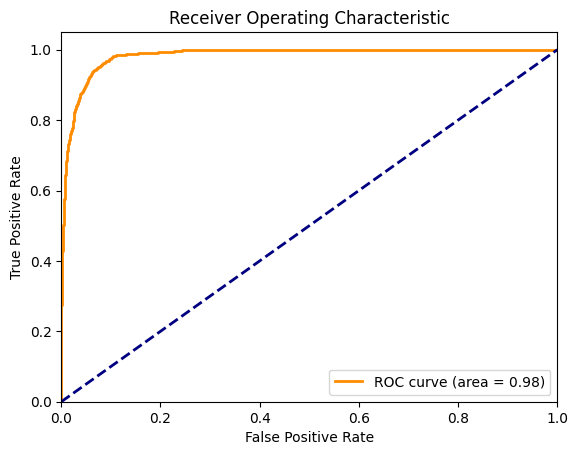

In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

W've got a great curve

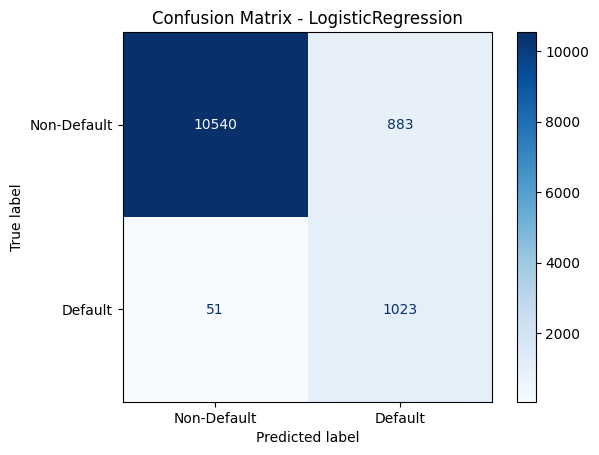

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = best_model.predict(X_test_encoded)
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Default', 'Default']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - LogisticRegression')
plt.show()

In [ ]:
y_train.shape

(37488,)

## Model Evaluation : Rankordering, KS statistic, Gini coeff


we are interesed in only the default rows( default 1)

In [ ]:
best_model.predict_proba(X_test_encoded)
                         

array([[0.43785832, 0.56214168],
       [0.99995736, 0.00004264],
       [0.99064705, 0.00935295],
       ...,
       [0.99426404, 0.00573596],
       [0.17970846, 0.82029154],
       [0.39424129, 0.60575871]], shape=(12497, 2))

In [ ]:
probabilities = best_model.predict_proba(X_test_encoded)[:,1] # [:, 1] means all the values in the 1st index. 0th col for non-default , 1st for default

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})
df_eval.head(3)

,Default Truth,Default Probability
19205,0,0.56
15514,0,0.00
30367,0,0.01


In [ ]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels = False , duplicates= 'drop')
df_eval.head()

,Default Truth,Default Probability,Decile
19205,0,0.56,8
15514,0,0.00,2
30367,0,0.01,6
35347,0,0.01,6
41814,1,0.93,9


adding min prob. , max prob. , events, non-events

In [ ]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),    
}))
df_decile.reset_index(inplace=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.00,0.00,0.00,1250.00
1,1,0.00,0.00,0.00,1250.00
2,2,0.00,0.00,0.00,1249.00
3,3,0.00,0.00,0.00,1250.00
4,4,0.00,0.00,0.00,1250.00
5,5,0.00,0.01,0.00,1249.00
6,6,0.01,0.05,4.00,1246.00
7,7,0.05,0.26,11.00,1238.00
8,8,0.27,0.82,157.00,1093.00
9,9,0.82,1.00,902.00,348.00


Event rate and non-event rate

In [ ]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,0,0.00,0.00,0.00,1250.00,0.00,100.00
1,1,0.00,0.00,0.00,1250.00,0.00,100.00
2,2,0.00,0.00,0.00,1249.00,0.00,100.00
3,3,0.00,0.00,0.00,1250.00,0.00,100.00
4,4,0.00,0.00,0.00,1250.00,0.00,100.00
5,5,0.00,0.01,0.00,1249.00,0.00,100.00
6,6,0.01,0.05,4.00,1246.00,0.32,99.68
7,7,0.05,0.26,11.00,1238.00,0.88,99.12
8,8,0.27,0.82,157.00,1093.00,12.56,87.44
9,9,0.82,1.00,902.00,348.00,72.16,27.84


In [ ]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.82,1.00,902.00,348.00,72.16,27.84
1,8,0.27,0.82,157.00,1093.00,12.56,87.44
2,7,0.05,0.26,11.00,1238.00,0.88,99.12
3,6,0.01,0.05,4.00,1246.00,0.32,99.68
4,5,0.00,0.01,0.00,1249.00,0.00,100.00
5,4,0.00,0.00,0.00,1250.00,0.00,100.00
6,3,0.00,0.00,0.00,1250.00,0.00,100.00
7,2,0.00,0.00,0.00,1249.00,0.00,100.00
8,1,0.00,0.00,0.00,1250.00,0.00,100.00
9,0,0.00,0.00,0.00,1250.00,0.00,100.00


In [ ]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile
# cumsum means cumulative sum

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.82,1.00,902.00,348.00,72.16,27.84,902.00,348.00
1,8,0.27,0.82,157.00,1093.00,12.56,87.44,1059.00,1441.00
2,7,0.05,0.26,11.00,1238.00,0.88,99.12,1070.00,2679.00
3,6,0.01,0.05,4.00,1246.00,0.32,99.68,1074.00,3925.00
4,5,0.00,0.01,0.00,1249.00,0.00,100.00,1074.00,5174.00
5,4,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,6424.00
6,3,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,7674.00
7,2,0.00,0.00,0.00,1249.00,0.00,100.00,1074.00,8923.00
8,1,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,10173.00
9,0,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,11423.00


In [ ]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.82,1.00,902.00,348.00,72.16,27.84,902.00,348.00,83.99,3.05
1,8,0.27,0.82,157.00,1093.00,12.56,87.44,1059.00,1441.00,98.60,12.61
2,7,0.05,0.26,11.00,1238.00,0.88,99.12,1070.00,2679.00,99.63,23.45
3,6,0.01,0.05,4.00,1246.00,0.32,99.68,1074.00,3925.00,100.00,34.36
4,5,0.00,0.01,0.00,1249.00,0.00,100.00,1074.00,5174.00,100.00,45.29
5,4,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,6424.00,100.00,56.24
6,3,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,7674.00,100.00,67.18
7,2,0.00,0.00,0.00,1249.00,0.00,100.00,1074.00,8923.00,100.00,78.11
8,1,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,10173.00,100.00,89.06
9,0,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,11423.00,100.00,100.00


In [ ]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.82,1.00,902.00,348.00,72.16,27.84,902.00,348.00,83.99,3.05,80.94
1,8,0.27,0.82,157.00,1093.00,12.56,87.44,1059.00,1441.00,98.60,12.61,85.99
2,7,0.05,0.26,11.00,1238.00,0.88,99.12,1070.00,2679.00,99.63,23.45,76.17
3,6,0.01,0.05,4.00,1246.00,0.32,99.68,1074.00,3925.00,100.00,34.36,65.64
4,5,0.00,0.01,0.00,1249.00,0.00,100.00,1074.00,5174.00,100.00,45.29,54.71
5,4,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,6424.00,100.00,56.24,43.76
6,3,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,7674.00,100.00,67.18,32.82
7,2,0.00,0.00,0.00,1249.00,0.00,100.00,1074.00,8923.00,100.00,78.11,21.89
8,1,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,10173.00,100.00,89.06,10.94
9,0,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,11423.00,100.00,100.00,0.00


To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).

**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

### The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (If KS is in top 3 decile and score above 40, it is considered a good predictive model.)The maximum KS value should be in the top 3

In [191]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9837023085998373
Gini Coefficient: 0.9674046171996746


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

### Finalize the model

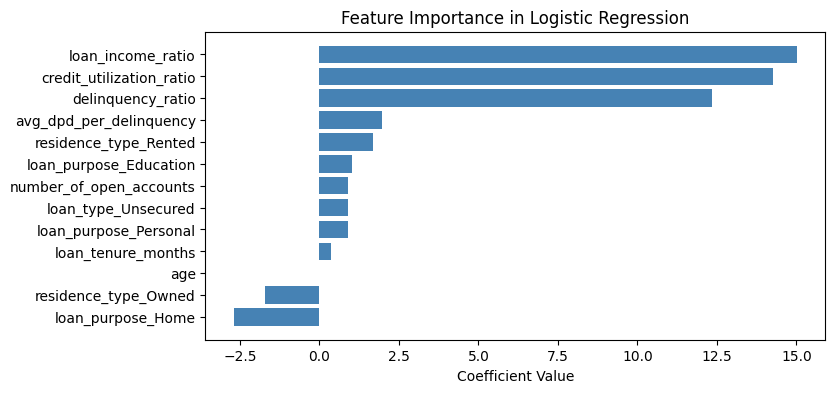

In [190]:
final_model = best_model

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [180]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='str')

In [181]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_income_ratio', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='str')

In [ ]:
cols_to_scale

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_income_ratio',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [192]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data.joblib']